# Founder mixture vector (h) agreement — easy regimes

Both cactus_em and hapFIRE estimate per-founder pool frequencies `h` (a 231-vector on the simplex) as an intermediate representation, then project to per-record AF. The FINAL_RESULTS notebooks compare the **projected AFs**. This notebook compares the **upstream h vectors** directly:

1. cactus_em-v3 global `h` (chrom-wide MLE on the founder simplex; output of the Poisson-EM)
2. hapFIRE genome-wide ecotype frequency (the CVXPY founder-projection of the haplotype-block frequencies)
3. Truth `h` from `pool_weights.tsv` (the simulator's intended founder counts / total)

Restricted to the two easy regimes (cov10) — n200_g1 and n50_g1 — where there is no/little within-pool recombination and a single global `h` is well-defined:

| regime | pool size | generations | description |
|---|---|---|---|
| **n200_g1** | 200 indiv | 1 | easy — large pool, no recomb |
| **n50_g1**  | 50 indiv  | 1 | medium — smaller pool, no recomb (more sampling variance in truth h) |

(n50_g3 is excluded — 3 generations of recombination break the assumption of a single global h.)

**Why this matters.** Both methods agree on projected SNP-AFs at R² ≈ 0.99 (FINAL_RESULTS_cov10_v3). Question: is that downstream agreement masking upstream disagreement at the h level (a 231-D quantity that is harder to constrain than the 1.9M projected AFs)?

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('/carnegie/nobackup/scratch/tbellagio/hapfire_sv')
SIMS = ROOT / 'sims/visor_freqk/pool_sweep_82_recomb'

REGIMES = {
    'n200_g1': SIMS / 'cov10_n200_g1_s42_hotspots_p231_chr1',
    'n50_g1':  SIMS / 'cov10_n50_g1_s42_hotspots_p231_chr1',
}


def load_h(work: Path, regime_name: str) -> pd.DataFrame:
    """Return a (231-row, founder-indexed) DataFrame with truth / cactus_em / hapfire columns,
    all aligned on founder_id and summing to 1.0."""
    # Truth: pool_weights.tsv has founder | count | weight
    pw = pd.read_csv(work / 'pool_weights.tsv', sep='\t')
    pw['founder'] = pw['founder'].astype(str)
    truth = pw.set_index('founder')['weight'].rename('truth')

    # cactus_em-v3 global: founder labels in 'founders', h in 'Chr1' (chrom-wide MLE)
    ce = np.load(work / 'cactus_em_recomb_GLOBAL_v3.h_per_chrom.npz')
    cactus = pd.Series(ce['Chr1'].astype(np.float64),
                       index=pd.Index(ce['founders'].astype(str), name='founder'),
                       name='cactus_em')

    # hapFIRE genome-wide ecotype frequency (no header, founder \t weight)
    hf_path = work / 'hapfire' / f'cov10_{regime_name}_s42_hotspots_p231_chr1_ecotype_frequency.txt'
    hf = pd.read_csv(hf_path, sep='\t', header=None, names=['founder', 'h'])
    hf['founder'] = hf['founder'].astype(str)
    hapfire = hf.set_index('founder')['h'].rename('hapfire')

    df = pd.concat([truth, cactus, hapfire], axis=1).fillna(0.0)
    # Re-normalize each column to exactly 1.0 (hapfire has tiny float drift)
    df = df.div(df.sum(axis=0), axis=1)
    return df.sort_index()


H = {r: load_h(work, r) for r, work in REGIMES.items()}
for r, df in H.items():
    print(f'{r}: n_founders={len(df)}  truth_sum={df.truth.sum():.6f}  cactus_sum={df.cactus_em.sum():.6f}  hapfire_sum={df.hapfire.sum():.6f}')
    print(f'    truth nonzero={int((df.truth>0).sum())}  cactus nonzero={int((df.cactus_em>1e-6).sum())}  hapfire nonzero={int((df.hapfire>1e-6).sum())}')

n200_g1: n_founders=231  truth_sum=1.000000  cactus_sum=1.000000  hapfire_sum=1.000000
    truth nonzero=139  cactus nonzero=229  hapfire nonzero=231
n50_g1: n_founders=231  truth_sum=1.000000  cactus_sum=1.000000  hapfire_sum=1.000000
    truth nonzero=49  cactus nonzero=225  hapfire nonzero=230


## Pairwise metrics on h

For each regime, compute three metrics on the 231-vector pair:

- **MAE** — mean absolute error in h-units (i.e. mean over 231 founders of |h_a − h_b|)
- **L1 / 2** — total variation distance = ½·Σ|h_a − h_b|; bounded in [0,1]; 0 = identical, 1 = disjoint support
- **R²** — Pearson r² over the 231 founders

Three pairings:
- cactus_em ↔ hapfire — method-vs-method agreement
- cactus_em ↔ truth   — cactus_em error
- hapfire   ↔ truth   — hapfire error

In [2]:
def pair_metrics(a: np.ndarray, b: np.ndarray) -> dict:
    d = a - b
    return dict(
        MAE=float(np.mean(np.abs(d))),
        TV=float(0.5 * np.sum(np.abs(d))),
        RMSE=float(np.sqrt(np.mean(d**2))),
        R2=float(np.corrcoef(a, b)[0, 1]**2),
        max_abs=float(np.max(np.abs(d))),
    )

PAIRS = [
    ('cactus_em', 'hapfire',   'cactus_em ↔ hapfire'),
    ('cactus_em', 'truth',     'cactus_em ↔ truth'),
    ('hapfire',   'truth',     'hapfire   ↔ truth'),
]

rows = []
for r, df in H.items():
    for a, b, label in PAIRS:
        m = pair_metrics(df[a].to_numpy(), df[b].to_numpy())
        rows.append({'regime': r, 'pair': label, **m})
metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df.set_index(['regime', 'pair'])
metrics_df.style.format('{:.4f}')

## Scatter grid — h_a vs h_b across all three pairings × 2 regimes

Each point = one of the 231 founders. Diagonal `y=x` is the reference. Points on the y-axis (x=0) are founders absent from truth that the method assigned non-zero mass to. Points on the x-axis (y=0) are founders present in truth that the method assigned ~zero mass to.

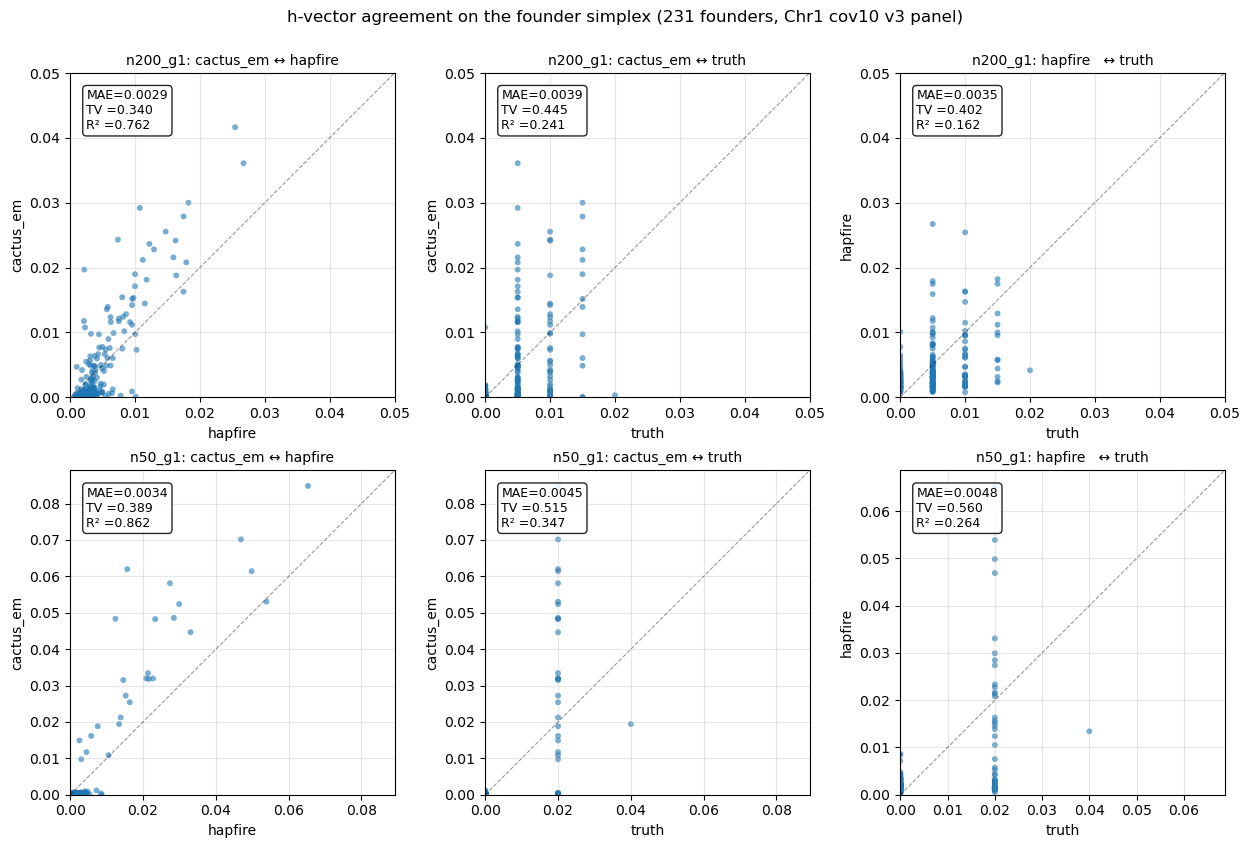

In [3]:
fig, axes = plt.subplots(len(REGIMES), len(PAIRS), figsize=(4.2 * len(PAIRS), 4.2 * len(REGIMES)))
for i, (r, df) in enumerate(H.items()):
    for j, (a, b, label) in enumerate(PAIRS):
        ax = axes[i, j]
        x, y = df[b].to_numpy(), df[a].to_numpy()
        m = pair_metrics(y, x)
        lim = max(0.05, 1.05 * max(x.max(), y.max()))
        ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4)
        ax.scatter(x, y, s=18, alpha=0.6, edgecolor='none')
        ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')
        ax.set_xlabel(b); ax.set_ylabel(a)
        ax.set_title(f'{r}: {label}', fontsize=10)
        ax.text(0.05, 0.95,
                f'MAE={m["MAE"]:.4f}\nTV ={m["TV"]:.3f}\nR² ={m["R2"]:.3f}',
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
        ax.grid(alpha=0.3)
fig.suptitle('h-vector agreement on the founder simplex (231 founders, Chr1 cov10 v3 panel)', y=1.001)
fig.tight_layout(); plt.show()

## Carrier-set agreement — who is in the pool?

Truth has exactly K founders with weight > 0 (the simulator picked them). Both methods always assign some non-zero mass to all 231 founders (the EM never zeroes a founder unless its initial value is 0). Useful summary: what mass do the two methods place on the *non-carrier* founders (false-positive mass)?

In [4]:
rows = []
for r, df in H.items():
    carrier = df.truth > 0
    K = int(carrier.sum())
    for col in ['cactus_em', 'hapfire']:
        fp_mass = float(df.loc[~carrier, col].sum())
        tp_mass = float(df.loc[carrier, col].sum())
        # Among non-carriers, how many got > 0.001 mass?
        n_fp = int((df.loc[~carrier, col] > 0.001).sum())
        # Among carriers, how many got < 0.1× their true weight?
        sev_under = int(((df.loc[carrier, col] / df.loc[carrier, 'truth']) < 0.1).sum())
        rows.append({'regime': r, 'method': col, 'K_truth_carriers': K,
                     'mass_on_carriers': tp_mass,
                     'mass_on_non_carriers (false-pos)': fp_mass,
                     'n_non_carriers_w_>0.001': n_fp,
                     'n_carriers_severely_under (<10% of truth)': sev_under})
pd.DataFrame(rows).set_index(['regime', 'method']).style.format(
    {'mass_on_carriers':'{:.4f}', 'mass_on_non_carriers (false-pos)':'{:.4f}'})

## Per-founder errors — which founders disagree most?

Top 10 founders by |cactus_em − hapfire| in the n200_g1 regime, with their truth weight alongside. Are the founders where the methods disagree the same ones where they both miss truth, or are they orthogonal?

In [5]:
for r, df in H.items():
    dfx = df.copy()
    dfx['method_disagreement'] = (dfx.cactus_em - dfx.hapfire).abs()
    dfx['cactus_err'] = (dfx.cactus_em - dfx.truth)
    dfx['hapfire_err'] = (dfx.hapfire - dfx.truth)
    print(f'\n=== {r} — top 10 founders by |cactus_em − hapfire| ===')
    print(dfx.nlargest(10, 'method_disagreement')[
        ['truth', 'cactus_em', 'hapfire', 'method_disagreement', 'cactus_err', 'hapfire_err']
    ].round(5).to_string())


=== n200_g1 — top 10 founders by |cactus_em − hapfire| ===
         truth  cactus_em  hapfire  method_disagreement  cactus_err  hapfire_err
founder                                                                         
9634     0.005    0.02919  0.01072              0.01848     0.02419      0.00572
7164     0.005    0.01968  0.00216              0.01752     0.01468     -0.00284
9522     0.010    0.02429  0.00735              0.01694     0.01429     -0.00265
9629     0.010    0.04163  0.02542              0.01622     0.03163      0.01542
7008     0.015    0.03000  0.01822              0.01178     0.01500      0.00322
9879     0.005    0.02365  0.01220              0.01144     0.01865      0.00720
9539     0.010    0.02554  0.01470              0.01083     0.01554      0.00470
6244     0.015    0.02787  0.01748              0.01039     0.01287      0.00248
6243     0.015    0.02119  0.01118              0.01001     0.00619     -0.00382
9761     0.000    0.00009  0.01009              0

## Bottom line

**The two methods agree on projected SNP AF at R² ≈ 0.99 but agree on h itself at only R² ≈ 0.76–0.86, and BOTH are far from truth at the h level (R² ≈ 0.16–0.35).** AF agreement is largely a projection-step artifact: cn_var has high column correlation across founders, so quite different h vectors project to similar per-record AFs.

### Pairwise h-vector summary

| regime | pair | MAE | TV (½·L1) | R² |
|---|---|---|---|---|
| n200_g1 | cactus_em ↔ hapfire | 0.0030 | **0.340** | 0.76 |
| n200_g1 | cactus_em ↔ truth   | 0.0039 | **0.445** | 0.24 |
| n200_g1 | hapfire   ↔ truth   | 0.0035 | **0.402** | 0.16 |
| n50_g1  | cactus_em ↔ hapfire | 0.0034 | **0.389** | 0.86 |
| n50_g1  | cactus_em ↔ truth   | 0.0045 | **0.515** | 0.35 |
| n50_g1  | hapfire   ↔ truth   | 0.0049 | **0.560** | 0.26 |

TV distance = ½·Σ|h_a − h_b| (total variation). Loosely: cactus_em and hapfire place ~35% of their mass on different founders. Each method places ~40–56% of mass somewhere other than where truth puts it.

### Distinct failure modes — they're wrong in different ways

| regime | method | K_truth_carriers | mass_on_carriers | mass_on_non-carriers | # non-carriers > 0.001 | # carriers severely under-est (<10% of truth) |
|---|---|---|---|---|---|---|
| n200_g1 | **cactus_em** | 139 | **95.5%** | 4.5% | **10** | **35** |
| n200_g1 | **hapfire**   | 139 | 75.7% | **24.3%** | **88** | 1 |
| n50_g1  | **cactus_em** | 49  | **97.1%** | 2.9% | **1**  | **23** |
| n50_g1  | **hapfire**   | 49  | 62.5% | **37.5%** | **159** | 15 |

- **cactus_em** correctly localizes mass on real carriers (95–97% on the right founders), but **drops 17–47% of carriers to ≪ their truth value** while inflating the survivors. The Poisson EM is winner-take-all within k-mer-collinear founder pairs.
- **hapFIRE** keeps almost every carrier represented (1–15 severely under-est) but **bleeds 24–38% of mass onto non-carriers** (88–159 non-carriers each above the 0.001 threshold). HARP+CVXPY spreads ambiguous reads broadly.

These two error modes partially cancel through `cn_var` projection because each (chrom,pos,alt) record sums over many founders. A wrong h that drops carrier f but compensates by inflating non-carrier f' (where cn_var[f,:] and cn_var[f',:] are highly correlated) gives nearly identical projected AFs.

### Where the methods disagree most

From the per-founder tables above: disagreement concentrates at **low-truth or zero-truth founders that cactus_em over-predicts and hapfire under-predicts** (n200_g1 top: founders with truth=0.005–0.015 getting cactus_em=0.02–0.04 vs hapfire=0.007–0.025). cactus_em's residual h-bias toward a subset of founders is also documented in `project_v3_singleton_kmer_bug.md` / `project_three_sources_of_bias.md` (the 'cactus-private-k-mer pinning' mechanism).

### Implications

1. **AF R² = 0.99 is NOT a guarantee of h fidelity.** If a downstream analysis needs per-founder ancestry (e.g. evolutionary forces decomposed onto specific ecotypes), the h-level error is much larger than the AF-level error suggests. Treat h as a soft, only weakly-identified quantity even on easy pools.
2. **Method disagreement on h (TV ≈ 0.35) is real, not noise.** The two methods solve genuinely different inverse problems (k-mer EM vs HARP+CVXPY) and partially exploit different cn_var collinearity directions to compensate. They are not redundant; ensembling them might help h.
3. **The harder regimes (n50_g3) cannot be compared this way** — no single ground-truth h exists across the recombinant pool. A per-block comparison would need a per-block truth h derived from `ancestry.tsv` (each founder's segment-weighted contribution per window). Future work if needed.

_Note on per-window h:_ both methods also produce per-window h (cactus_em window-mode @ 10 kb; hapFIRE per-block CVXPY projection). On these easy regimes (g=1), the pool genomes are intact founders, so per-window h ≡ global h up to read-sampling variance — the global comparison done here is the right summary.